In [138]:
import os
import torch
from gsplat import rasterization
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')  # Adjust the path as necessary to locate the gsplat root directory
from mine.loader import initialize_model_from_ply_file
from examples.datasets.blender_nerf_synthetic import Parser, Dataset

%matplotlib inline
plt.rcParams['figure.figsize'] = (15.0, 12.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
%load_ext autoreload
%autoreload 2

device = torch.device("cuda:0")

from dev_refraction.refraction_transform import *



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [139]:
# Select the dataset
wo_refraction_dataset_path = os.path.abspath("../../../../dataset/river1/river_wo-refraction")
with_refraction_dataset_path = os.path.abspath("../../../../dataset/river1/river_with-refraction")
# Select trained model path
non_refraction_model_path = os.path.abspath('../../results/favo/river_wo-refraction/ply/point_cloud_29999.ply')

# Load the dataset
parser_ref = Parser(
    data_dir=wo_refraction_dataset_path,
)
dataset_ref = Dataset(
    parser_ref,
    split="train",
)

dataloader_ref = torch.utils.data.DataLoader(
    dataset_ref,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    pin_memory=True,
)

Loading 3D point cloud from: /home/taiki/dataset/river1/river_wo-refraction/points3d.ply
[Parser] Loaded 61 images from /home/taiki/dataset/river1/river_wo-refraction.


In [ ]:
data = dataloader_ref.dataset[50]

# extract data
camtoworlds = data["camtoworld"].view(1,4,4).to(device)  # [1, 4, 4] 
# camtoworlds[:, 0, 3] *= -1 # 鉛直下向きではこれでうまくレンダリングできる
print(f"camtoworlds :\n", camtoworlds)
worldtocam = camtoworlds.inverse()
print(f"worldtocam :\n", worldtocam)
cam_center = camtoworlds[0, :3, 3].detach().clone()
Ks = data["K"].view(1,3,3).to(device)  # [1, 3, 3]
pixels = data["image"].unsqueeze(0).to(device) / 255.0  # [1, H, W, 3]
image_ids = data["image_id"]
height, width = pixels.shape[1:3]

image_name = "train", f"{image_ids:04d}" + ".png"
print(image_name)


camtoworlds :
 tensor([[[-0.9397,  0.2620, -0.2198, 10.9923],
         [ 0.3420,  0.7198, -0.6040, 30.2011],
         [ 0.0000, -0.6428, -0.7660, 18.3022],
         [ 0.0000,  0.0000,  0.0000,  1.0000]]], device='cuda:0')
worldtocam :
 tensor([[[-9.3969e-01,  3.4202e-01, -1.3240e-08, -5.3970e-07],
         [ 2.6200e-01,  7.1985e-01, -6.4279e-01, -1.2856e+01],
         [-2.1985e-01, -6.0402e-01, -7.6604e-01,  3.4679e+01],
         [-4.4217e-10,  3.1477e-10, -1.3227e-09,  1.0000e+00]]],
       device='cuda:0')
('train', '0050.png')


In [150]:
# get Gaussian model from ply file
gs_model_gt = initialize_model_from_ply_file(non_refraction_model_path, device=device)
# get each parameters as tensor from Gaussian model  torch.from_numpy
means     = gs_model_gt.gaussians["means"]      # shape: [N, 3]
scales    = gs_model_gt.gaussians["scales"]     # shape: [N, 3]
quats     = gs_model_gt.gaussians["rotations"]  # shape: [N, 4]
opacities = gs_model_gt.gaussians["opacities"].squeeze(-1)   # shape: (N,)
colors    = gs_model_gt.gaussians["shs"]        # shape: [N, 16, 3]


In [151]:
# Setting Refraction Parameters
n = 1.33
plane = 0.0
num_newton_iters = 10
newton_atol = 1e-6

RT = RefractionTransform(
    means=means,
    quats=quats,
    cam_center=cam_center,
    n=n,
    plane=plane,
    num_newton_iters=num_newton_iters,
    newton_atol=newton_atol,
)

trandformed_means = RT.transform_to_appearance()
dra_dr = RT.dra_dr()
dra_dz = RT.dra_dz()
dza_dr = RT.dza_dr()
dza_dz = RT.dza_dz()
jacobian = RT.dPa_dP()

In [ ]:
# 補正前の Gaussian を用いてレンダリング
rgb_wo_refraction, _, _ = rasterization(
    means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,  # Notice! Render world to cam matrix 
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_wo_refraction = rgb_wo_refraction.squeeze().cpu().detach().numpy()


In [ ]:
# 補正後の Gaussian を用いてレンダリング
rgb_refraction, _, _ = rasterization(
    trandformed_means,
    quats,
    scales,
    opacities,
    colors,
    worldtocam,
    Ks,
    width,
    height,
    sh_degree=0,
    rasterize_mode="antialiased"
)
rgb_refraction = rgb_refraction.squeeze().cpu().detach().numpy()


GT image without refraction: /home/taiki/dataset/river1/river_wo-refraction/train/0050.png
GT image with refraction: /home/taiki/dataset/river1/river_with-refraction/train/0050.png


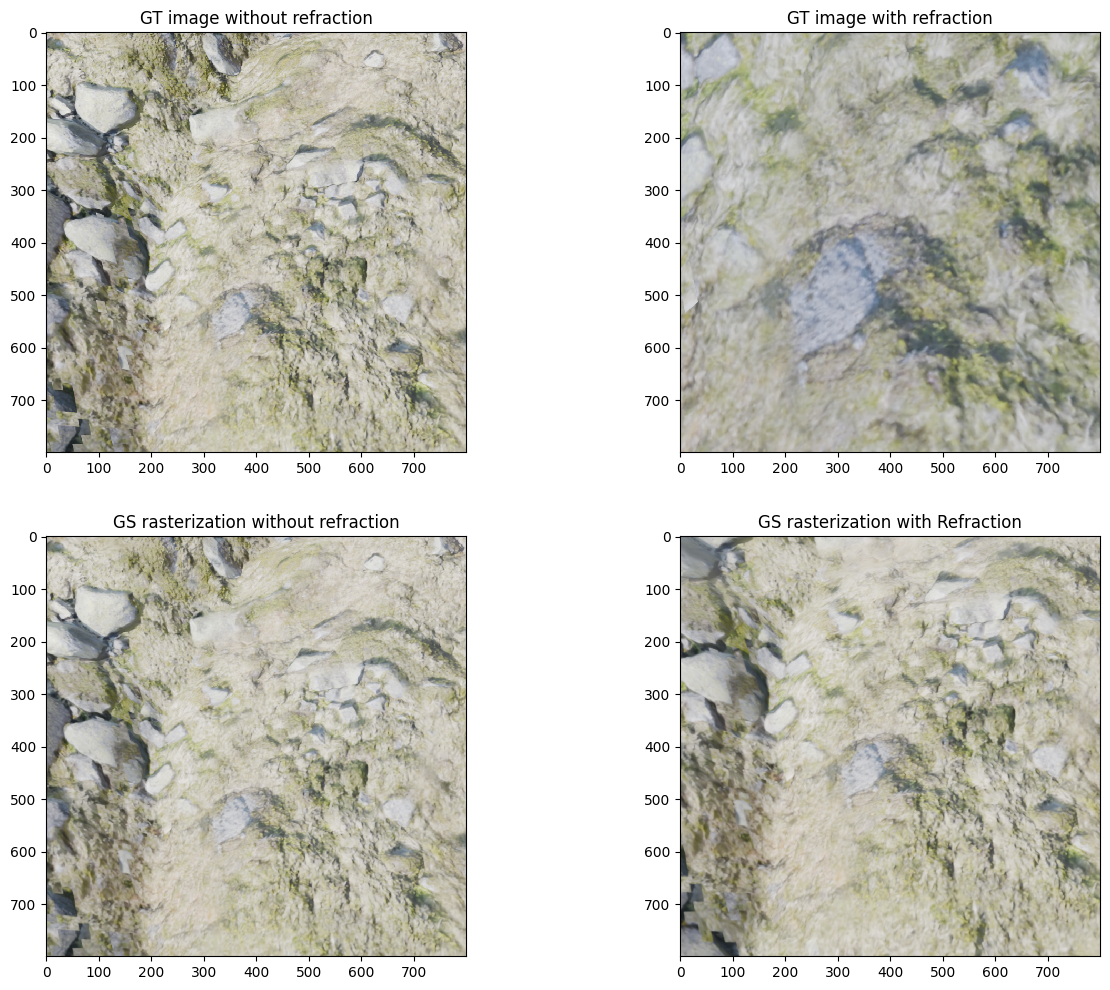

In [154]:
# Display
gt_image_path_wo_ref = os.path.join(wo_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_wo_ref = plt.imread(gt_image_path_wo_ref)
print(f"GT image without refraction: {gt_image_path_wo_ref}")

gt_image_path_with_ref = os.path.join(with_refraction_dataset_path, "train", f"{image_ids:04d}" + ".png")
gt_image_with_ref = plt.imread(gt_image_path_with_ref)
print(f"GT image with refraction: {gt_image_path_with_ref}")

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(gt_image_wo_ref)
ax[0, 0].set_title("GT image without refraction")
ax[0, 1].imshow(gt_image_with_ref)
ax[0, 1].set_title("GT image with refraction")
ax[1, 0].imshow(rgb_wo_refraction)
ax[1, 0].set_title("GS rasterization without refraction")
ax[1, 1].imshow(rgb_refraction)
ax[1, 1].set_title("GS rasterization with Refraction")
plt.show()

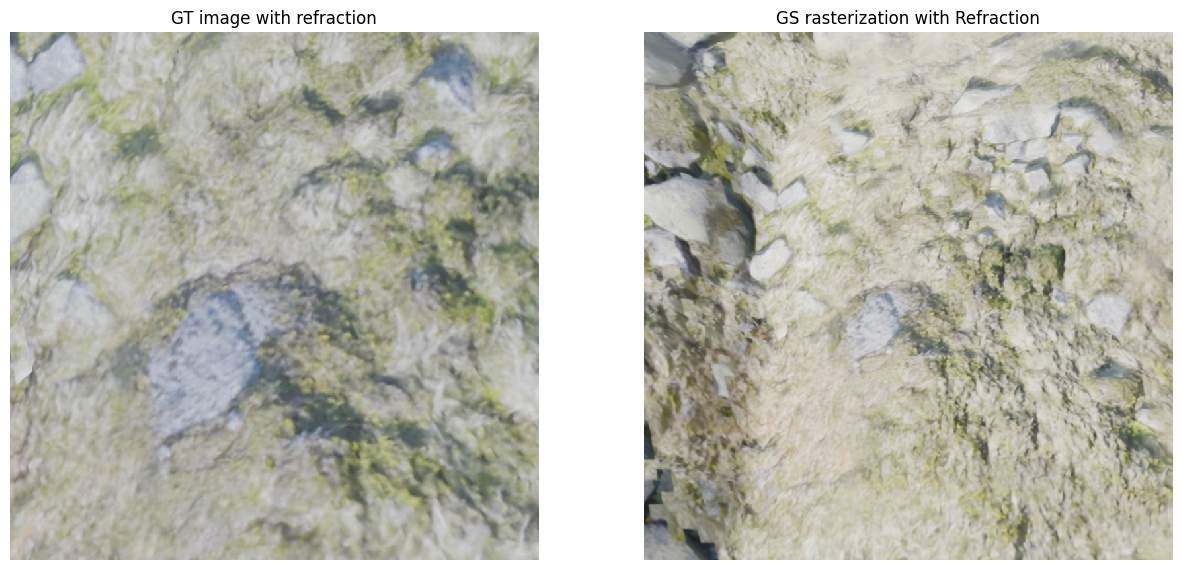

In [155]:
fig, ax = plt.subplots(1, 2)
# no axis
ax[0].axis("off")
ax[0].imshow(gt_image_with_ref)
ax[0].set_title("GT image with refraction")
ax[1].axis("off")
ax[1].imshow(rgb_refraction)
ax[1].set_title("GS rasterization with Refraction")

plt.show()

# 数値計算 VS 理論計算

In [156]:
# Output inner values
print("RT inner values:")
for key, value in vars(RT).items():
    print(f"{key}: {value}")

RT inner values:
device: cuda:0
n: 1.3300000429153442
plane: 0.0
delta: 0.01
num_newton_iters: 10
newton_atol: 1e-06
means: Parameter containing:
tensor([[  12.6821,   10.8150,  -23.9940],
        [  -0.8581,  -14.0744,  -21.4376],
        [  23.5191,   -8.0418,  -13.2078],
        ...,
        [-346.8394,  442.3927,  459.2708],
        [  21.7080,   23.7927,  -29.4693],
        [  24.4346,    9.3952,  -13.4968]], device='cuda:0',
       requires_grad=True)
quats: Parameter containing:
tensor([[-0.2932,  0.7565,  0.5208, -0.2655],
        [ 0.0981,  0.3448,  0.3824,  0.8516],
        [ 0.3418,  0.3260,  0.6774,  0.5640],
        ...,
        [-0.1517,  0.8751, -0.3411, -0.3080],
        [-0.4718, -0.1121,  0.4473,  0.7515],
        [ 0.5136,  0.2764,  0.6634,  0.4688]], device='cuda:0',
       requires_grad=True)
num_g: 1000000
cam_center: tensor([10.9923, 30.2011, 18.3022], device='cuda:0')
x0: 10.992313385009766
y0: 30.201141357421875
H: 18.302223205566406
x: tensor([   1.6897,  -11.

In [157]:
# output all camera to world matrices from parser   
for i in range(len(parser_ref.camtoworlds)):
    print(f"camtoworlds_original[{i}]: \n{parser_ref.camtoworlds[i]}\n")



camtoworlds_original[0]: 
[[  1.        -0.        -0.       -12.603736]
 [  0.        -1.        -0.       -12.603736]
 [  0.        -0.        -1.        30.      ]
 [  0.         0.         0.         1.      ]]

camtoworlds_original[1]: 
[[  1.        -0.        -0.       -12.603736]
 [  0.        -1.        -0.        -6.301868]
 [  0.        -0.        -1.        30.      ]
 [  0.         0.         0.         1.      ]]

camtoworlds_original[2]: 
[[  1.        -0.        -0.       -12.603736]
 [  0.        -1.        -0.         0.      ]
 [  0.        -0.        -1.        30.      ]
 [  0.         0.         0.         1.      ]]

camtoworlds_original[3]: 
[[  1.        -0.        -0.       -12.603736]
 [  0.        -1.        -0.         6.301868]
 [  0.        -0.        -1.        30.      ]
 [  0.         0.         0.         1.      ]]

camtoworlds_original[4]: 
[[  1.        -0.        -0.       -12.603736]
 [  0.        -1.        -0.        12.603736]
 [  0.        -0